# Sales Performance Analysis
### Global Electronics Retailer — 2016–2021

**Author:** _Your Name_
**Dataset:** [Global Electronics Retailer](https://mavenanalytics.io/data-playground/global-electronics-retailer) (Maven Analytics), 5 relational tables: Sales, Products, Customers, Stores, Exchange Rates.

This notebook is module 1 of 4 in the full analysis (Sales Performance · Geographic Performance · Product Performance · Customer Segmentation). It focuses on **overall sales and profit performance**: how the business has grown, how revenue splits across channels, and how reliable the underlying transaction data actually is.


## 1. Research Questions

1. How has revenue and profit evolved between 2016 and 2021, and is the trend we see genuine business seasonality or a data artifact?
2. How much revenue comes from **In-Store vs. Online**, and do the two channels behave differently (order value, delivery)?
3. Is growth being driven by **volume** or by improving **margins**?
4. Are there weekly/order-level patterns (day-of-week, items per order) with operational implications (staffing, bundling)?


## 2. Methodology

**Data.** Sales.csv (62,884 line items, 2016-01-01 to 2021-02-20) joined with Products (price/cost/category), Stores (channel/location), and Customers (demographics).

**Revenue logic — important design decision.** `Products.csv` lists `Unit Price USD` and `Unit Cost USD` — the retailer's list price, already in USD. `Sales.Currency Code` records only which currency a given order was *settled* in locally; it is not a signal that the USD price needs converting. We therefore compute:

$$\text{Revenue}_{USD} = \text{Quantity} \times \text{Unit Price USD}, \qquad \text{Profit}_{USD} = \text{Revenue}_{USD} - \text{Quantity} \times \text{Unit Cost USD}$$

with **no** exchange-rate adjustment applied to these USD figures — this matches how the source dashboards computed revenue, and independent published breakdowns of this dataset confirm it's the intended approach. The `Exchange_Rates` table is only used later, separately, to *restate* USD revenue in local-currency terms for regional reporting — that's an additional view, never a "correction."

**Data quality checks performed** (details in Section 4):
- `Delivery Date` is missing for ~79% of rows. This is **not random**: it is populated for 100% of Online orders and 0% of In-Store orders (in-store purchases are collected on the spot, so there is nothing to "deliver"). We treat this as structural, not missing data to impute.
- A recurring ~37-day window with **zero orders** appears every year around mid-March–April. We verify this is a data-collection artifact, not real seasonality, and flag it wherever it would otherwise distort a trend chart.


In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import matplotlib.pyplot as plt

from data_prep import build_sales_fact_table
from viz_style import apply_style, COLORS, add_titles, add_source_note, money_formatter, pct_formatter

apply_style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

df = build_sales_fact_table()
print(f"{len(df):,} line items | {df['Order Number'].nunique():,} orders | "
      f"{df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
df.head(3)

62,884 line items | 26,326 orders | 2016-01-01 to 2021-02-20


,Order Number,Line Item,Order Date,Delivery Date,CustomerKey,StoreKey,ProductKey,Quantity,Currency Code,Product Name,...,Continent,Revenue_USD,Cost_USD,Profit_USD,Profit_Margin,Is_Delivered,Delivery_Lag_Days,Order_Year,Order_Month,Order_YearMonth
0,366000,1,2016-01-01,NaT,265598,10,1304,1,CAD,Contoso Lens Adapter M450 White,...,North America,68.00,31.27,36.73,0.54,False,NaN,2016,1,2016-01-01
1,366001,1,2016-01-01,2016-01-13,1269051,0,1048,2,USD,A. Datum SLR Camera X136 Silver,...,North America,854.00,282.94,571.06,0.67,True,12.00,2016,1,2016-01-01
2,366001,2,2016-01-01,2016-01-13,1269051,0,2007,1,USD,Fabrikam Microwave 1.5CuFt X1100 Black,...,North America,665.94,220.64,445.30,0.67,True,12.00,2016,1,2016-01-01


## 3. Headline Numbers

In [2]:
total_revenue = df["Revenue_USD"].sum()
total_profit = df["Profit_USD"].sum()
margin = total_profit / total_revenue
n_orders = df["Order Number"].nunique()
n_customers = df["CustomerKey"].nunique()

print(f"Total Revenue:      ${total_revenue:,.0f}")
print(f"Total Profit:       ${total_profit:,.0f}")
print(f"Overall Margin:     {margin*100:.1f}%")
print(f"Total Orders:       {n_orders:,}")
print(f"Unique Customers:   {n_customers:,}")
print(f"Avg. Order Value:   ${total_revenue/n_orders:,.0f}")

Total Revenue:      $55,755,480
Total Profit:       $32,662,688
Overall Margin:     58.6%
Total Orders:       26,326
Unique Customers:   11,887
Avg. Order Value:   $2,118


## 4. Findings

### 4.1 Revenue & Profit Trend — and a critical data-quality catch

Before trusting any "seasonal dip," we checked the daily order count and found a **~37-day span with literally zero orders every single year** (mid-March to late April, 2016–2020 alike). Because it recurs identically each year regardless of business conditions, this is a data-export artifact, not a real seasonal slowdown — and we flag it explicitly rather than describing it as "customers buy less in spring."

Once that artifact is accounted for, a second, *genuine* signal stands out: 2020 does **not** recover after the gap the way every prior year does — revenue stays depressed through the rest of 2020, consistent with real COVID-19 disruption to in-store retail.

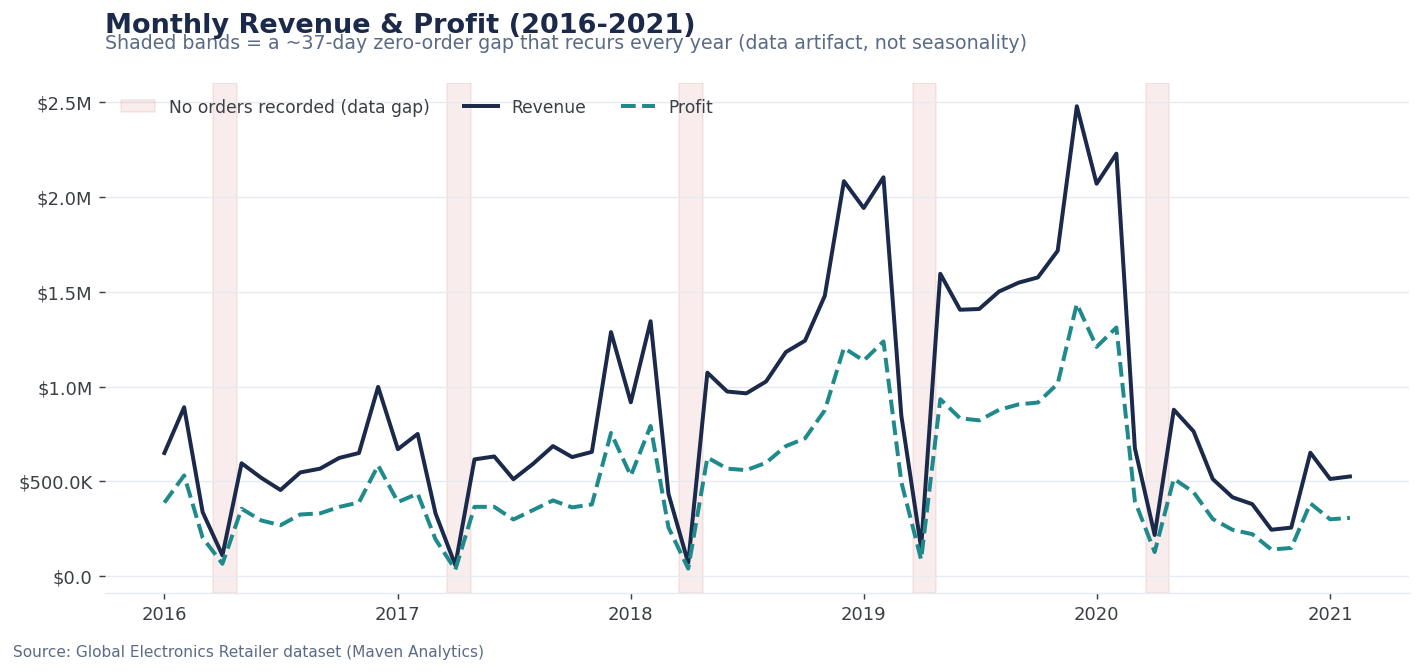

In [3]:
monthly = df.groupby("Order_YearMonth").agg(Revenue=("Revenue_USD","sum"), Profit=("Profit_USD","sum")).reset_index()

# Verified programmatically (see Appendix) - recurring zero-order windows
gap_windows = [
    ("2016-03-18", "2016-04-24"), ("2017-03-19", "2017-04-25"),
    ("2018-03-18", "2018-04-24"), ("2019-03-20", "2019-04-25"),
    ("2020-03-19", "2020-04-24"),
]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (start, end) in enumerate(gap_windows):
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color=COLORS["negative"], alpha=0.10,
               label="No orders recorded (data gap)" if i == 0 else None)
ax.plot(monthly["Order_YearMonth"], monthly["Revenue"], color=COLORS["primary"], linewidth=2.2, label="Revenue")
ax.plot(monthly["Order_YearMonth"], monthly["Profit"], color=COLORS["positive"], linewidth=2.2, label="Profit", linestyle="--")
ax.yaxis.set_major_formatter(money_formatter())
add_titles(ax, "Monthly Revenue & Profit (2016-2021)",
           "Shaded bands = a ~37-day zero-order gap that recurs every year (data artifact, not seasonality)")
ax.legend(loc="upper left", ncols=3, fontsize=9.5)
add_source_note(fig)
plt.tight_layout()
plt.savefig("../reports/figures/01_monthly_revenue_profit.png")
plt.show()

**Appendix check — proving the gap is an artifact, not seasonality:**

In [4]:
order_dates = pd.Series(sorted(df["Order Date"].dropna().unique()))
gap_days = order_dates.diff().dt.days
gaps = pd.DataFrame({"gap_starts_after": order_dates[:-1].values, "gap_length_days": gap_days[1:].values})
gaps[gaps["gap_length_days"] > 3]

,gap_starts_after,gap_length_days
70,2016-03-17,37.00
385,2017-03-18,38.00
704,2018-03-17,38.00
1033,2019-03-19,36.00
1363,2020-03-18,36.00


### 4.2 Year-over-Year Growth

2021 is excluded from this comparison — the dataset only contains January–February of that year, so a full-year comparison would be misleading.

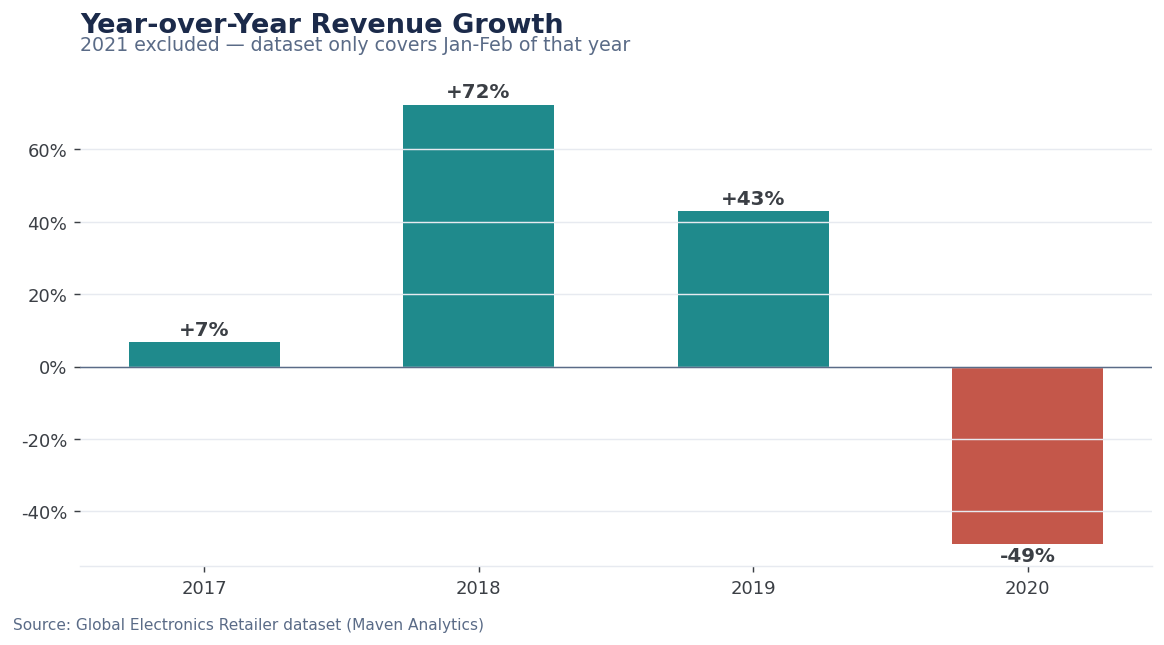

In [5]:
full_years = df[df["Order_Year"].between(2016, 2020)]
annual = full_years.groupby("Order_Year")["Revenue_USD"].sum()
yoy = annual.pct_change()

fig, ax = plt.subplots(figsize=(9, 4.8))
colors = [COLORS["positive"] if v >= 0 else COLORS["negative"] for v in yoy.values[1:]]
ax.bar(annual.index[1:].astype(str), yoy.values[1:], color=colors, width=0.55)
for i, v in enumerate(yoy.values[1:]):
    ax.text(i, v + (0.02 if v >= 0 else -0.045), f"{v*100:+.0f}%", ha="center", fontsize=11, fontweight="bold", color=COLORS["text"])
ax.yaxis.set_major_formatter(pct_formatter(0))
ax.axhline(0, color=COLORS["muted"], linewidth=0.8)
add_titles(ax, "Year-over-Year Revenue Growth", "2021 excluded — dataset only covers Jan-Feb of that year")
add_source_note(fig)
plt.tight_layout()
plt.savefig("../reports/figures/04_yoy_growth.png")
plt.show()

Strong growth in 2018 (+72%) and 2019 (+43%) was followed by a sharp -49% contraction in 2020 — the COVID-19 effect visible in 4.1 dominates the annual figure.

### 4.3 Is growth from volume or margin?

Margin has stayed remarkably flat (58-59%) every year. This tells us growth in 2018-2019 came from selling **more units to more customers**, not from repricing or a shift toward higher-margin products — and the 2020 decline is a volume story too, not a margin collapse.

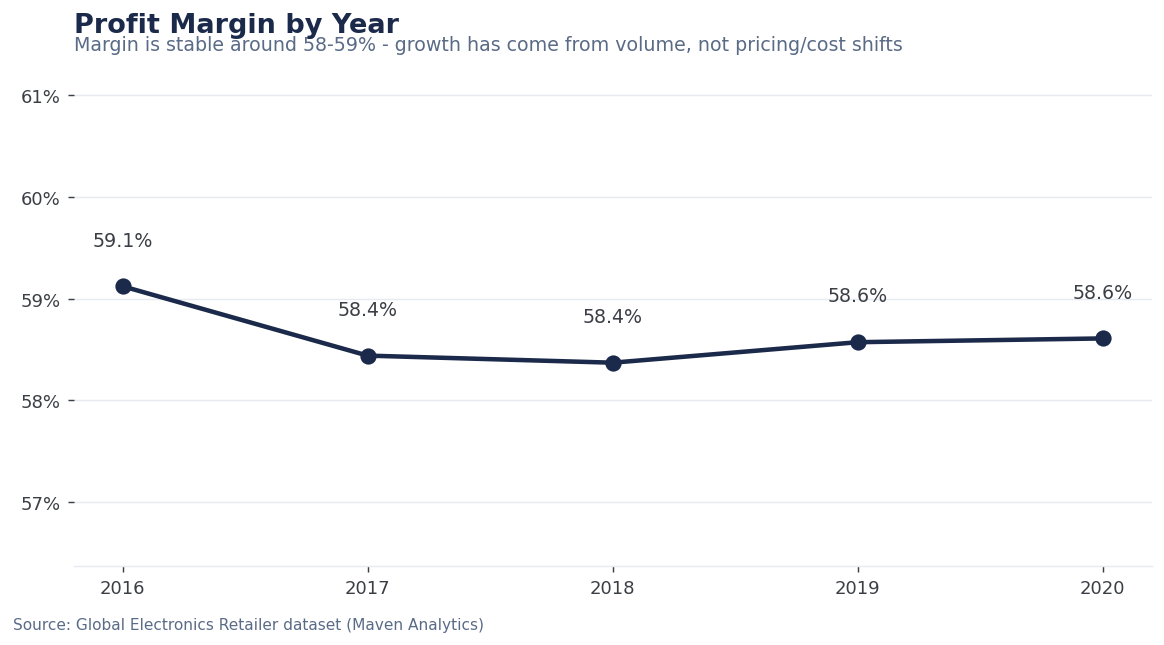

In [6]:
annual_margin = full_years.groupby("Order_Year").apply(lambda g: g["Profit_USD"].sum() / g["Revenue_USD"].sum())

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.plot(annual_margin.index.astype(str), annual_margin.values, marker="o", markersize=8, color=COLORS["primary"], linewidth=2.5)
for i, v in enumerate(annual_margin.values):
    ax.text(i, v + 0.004, f"{v*100:.1f}%", ha="center", fontsize=10.5, color=COLORS["text"])
ax.yaxis.set_major_formatter(pct_formatter(0))
ax.set_ylim(annual_margin.min() - 0.02, annual_margin.max() + 0.02)
add_titles(ax, "Profit Margin by Year", "Margin is stable around 58-59% - growth has come from volume, not pricing/cost shifts")
add_source_note(fig)
plt.tight_layout()
plt.savefig("../reports/figures/05_profit_margin_trend.png")
plt.show()

### 4.4 In-Store vs. Online

In-Store still generates about 4x the revenue of Online, but that's almost entirely a **volume** effect — Average Order Value is nearly identical between the two channels ($2,138 vs $2,044). Online is not a "smaller-basket" channel; it simply has fewer orders.

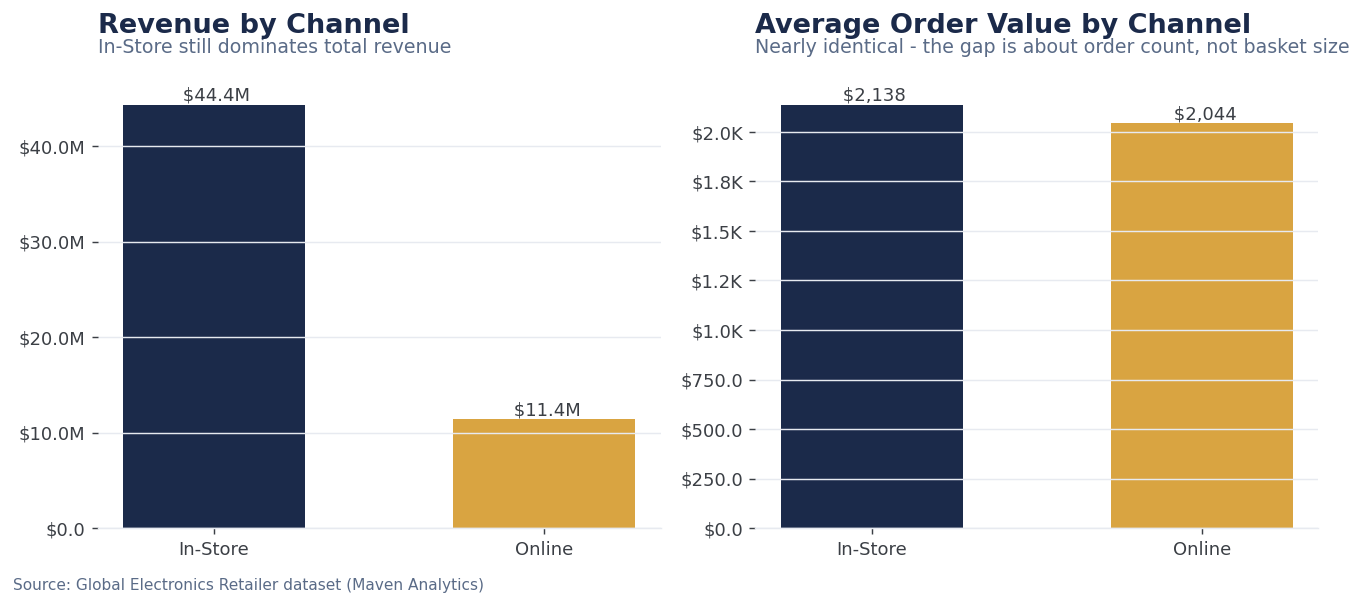

In [7]:
order_level = df.groupby(["Order Number", "Store Type"]).agg(Order_Value=("Revenue_USD", "sum")).reset_index()
aov = order_level.groupby("Store Type")["Order_Value"].mean()
rev_share = df.groupby("Store Type")["Revenue_USD"].sum()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(rev_share.index, rev_share.values, color=[COLORS["primary"], COLORS["accent"]], width=0.55)
axes[0].yaxis.set_major_formatter(money_formatter())
add_titles(axes[0], "Revenue by Channel", "In-Store still dominates total revenue")
for i, v in enumerate(rev_share.values):
    axes[0].text(i, v, f" ${v/1e6:.1f}M", ha="center", va="bottom", fontsize=10, color=COLORS["text"])

axes[1].bar(aov.index, aov.values, color=[COLORS["primary"], COLORS["accent"]], width=0.55)
axes[1].yaxis.set_major_formatter(money_formatter())
add_titles(axes[1], "Average Order Value by Channel", "Nearly identical - the gap is about order count, not basket size")
for i, v in enumerate(aov.values):
    axes[1].text(i, v, f" ${v:,.0f}", ha="center", va="bottom", fontsize=10, color=COLORS["text"])
add_source_note(fig)
plt.tight_layout()
plt.savefig("../reports/figures/02_channel_comparison.png")
plt.show()

### 4.5 Delivery Performance

A delivery date is recorded for **100% of Online orders and 0% of In-Store orders** — this is a structural fact of the business (in-store purchases are handed over immediately), not a data-quality problem to fix. Among Online orders, delivery takes 1-17 days, with a median of 4 days.

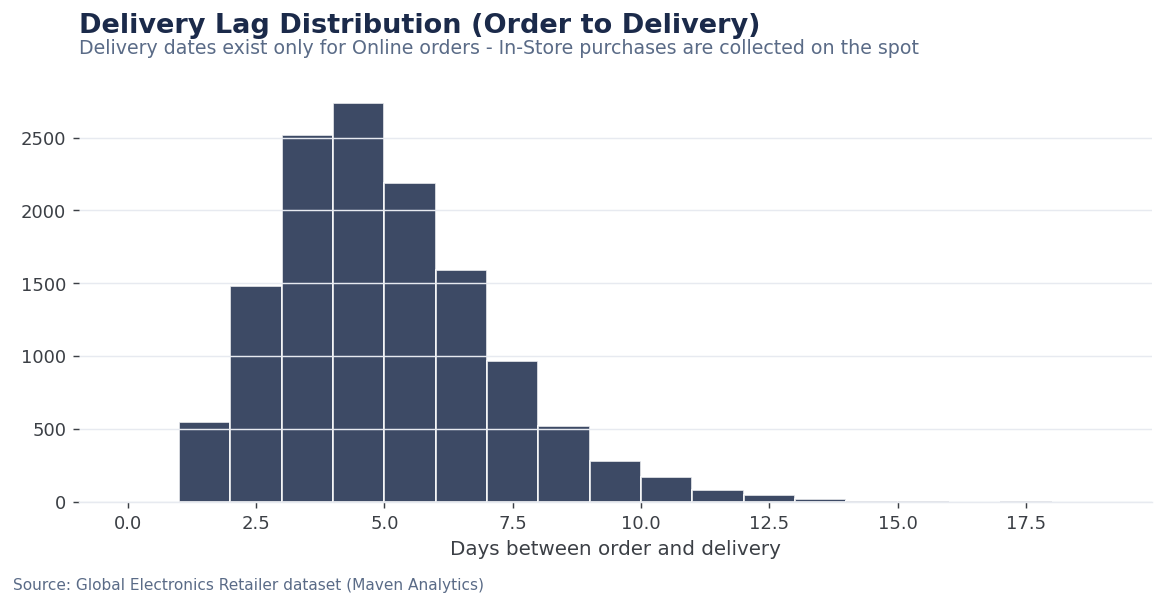

mean    4.53
50%     4.00
min     1.00
max    17.00
Name: Delivery_Lag_Days, dtype: float64


In [8]:
delivered = df[df["Is_Delivered"]]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(delivered["Delivery_Lag_Days"], bins=range(0, 20), color=COLORS["primary"], alpha=0.85, edgecolor="white")
add_titles(ax, "Delivery Lag Distribution (Order to Delivery)",
           "Delivery dates exist only for Online orders - In-Store purchases are collected on the spot")
ax.set_xlabel("Days between order and delivery")
add_source_note(fig)
plt.tight_layout()
plt.savefig("../reports/figures/03_delivery_lag.png")
plt.show()

print(delivered["Delivery_Lag_Days"].describe()[["mean","50%","min","max"]])

### 4.6 Day-of-Week Pattern

Revenue is not evenly spread across the week: **Saturday is the strongest day** and **Sunday is dramatically lower** (~85% below the weekday average) — consistent with many stores in the store network being closed or operating reduced hours on Sundays.

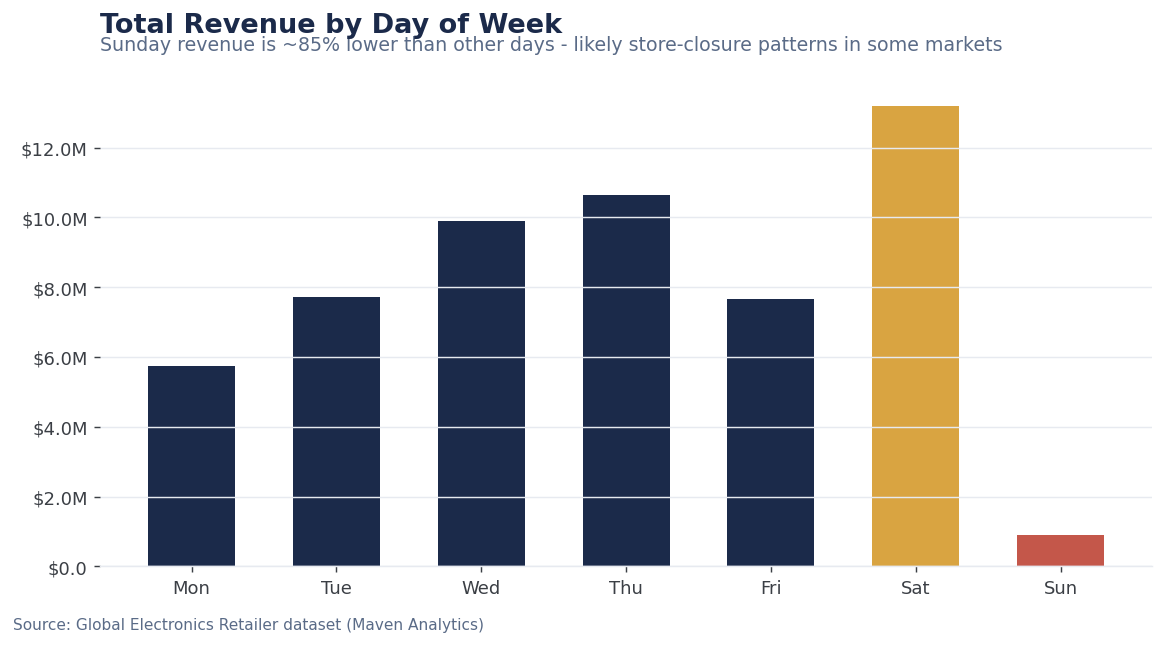

In [9]:
df["Weekday"] = df["Order Date"].dt.day_name()
weekday_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
by_weekday = df.groupby("Weekday")["Revenue_USD"].sum().reindex(weekday_order)

fig, ax = plt.subplots(figsize=(9, 4.8))
colors = [COLORS["negative"] if d == "Sunday" else (COLORS["accent"] if d == "Saturday" else COLORS["primary"]) for d in weekday_order]
ax.bar([d[:3] for d in weekday_order], by_weekday.values, color=colors, width=0.6)
ax.yaxis.set_major_formatter(money_formatter())
add_titles(ax, "Total Revenue by Day of Week", "Sunday revenue is ~85% lower than other days - likely store-closure patterns in some markets")
add_source_note(fig)
plt.tight_layout()
plt.savefig("../reports/figures/06_revenue_by_weekday.png")
plt.show()

### 4.7 Order Size

Most orders are small: **35% contain just one product**, and 81% contain three or fewer. Large basket sizes (5+ distinct products) are rare (under 3% each). This matters for any cross-sell/bundling strategy — there's clear room to grow basket size.

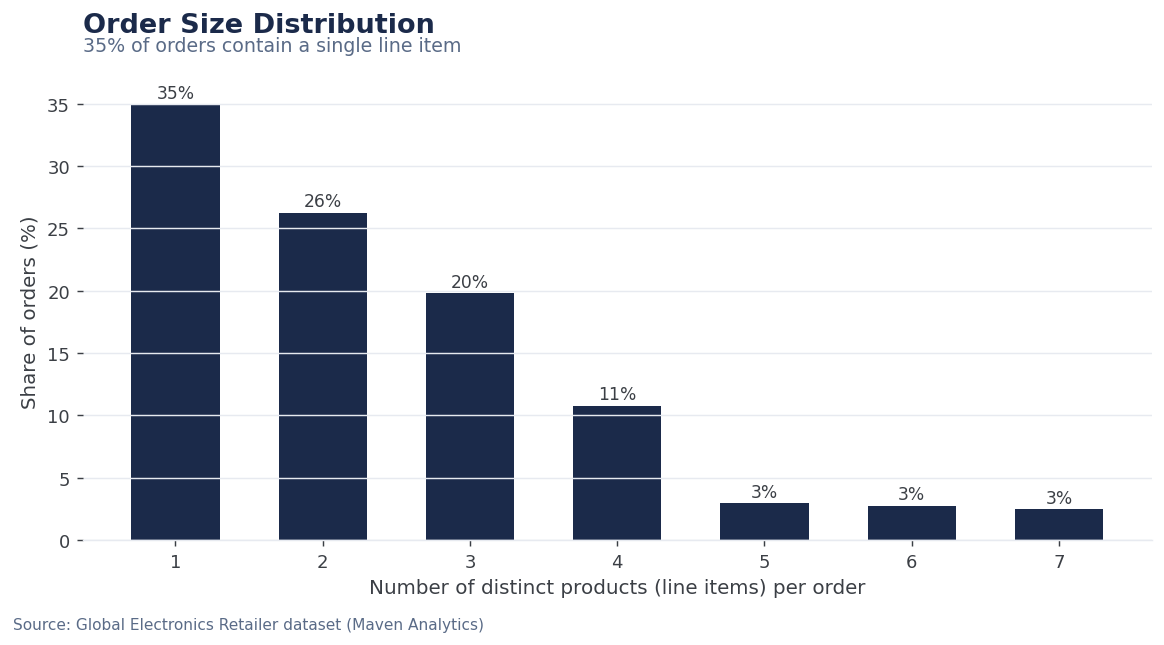

In [10]:
order_size = df.groupby("Order Number")["Line Item"].count()
size_dist = order_size.value_counts(normalize=True).sort_index() * 100

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.bar(size_dist.index.astype(str), size_dist.values, color=COLORS["primary"], width=0.6)
for i, v in enumerate(size_dist.values):
    if v > 1:
        ax.text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=9.5, color=COLORS["text"])
add_titles(ax, "Order Size Distribution", f"{size_dist.iloc[0]:.0f}% of orders contain a single line item")
ax.set_xlabel("Number of distinct products (line items) per order")
ax.set_ylabel("Share of orders (%)")
add_source_note(fig)
plt.tight_layout()
plt.savefig("../reports/figures/07_order_size_distribution.png")
plt.show()

## 5. Business Conclusions & Recommendations

1. **Fix the reporting pipeline, not the business.** The recurring 37-day data gap every March-April is almost certainly an ETL/export issue upstream. Any dashboard reporting "spring seasonality" today is misinforming stakeholders — this should be corrected at the source before any seasonal planning is done on top of it.

2. **The 2020 decline is real and did not recover by the end of the data window (Feb 2021).** Unlike the recurring gap, this is a genuine, sustained drop that deserves a channel-specific recovery plan (e.g., accelerating the Online channel, which is structurally unaffected by in-store closures).

3. **Growth has been volume-driven, with flat 58-59% margins.** There is currently no pricing/cost lever being pulled — margin-expansion initiatives (supplier renegotiation, premium mix shift) represent untapped upside that hasn't yet been tried.

4. **Online is not the "smaller-order" channel it's often assumed to be.** With AOV essentially matching In-Store ($2,044 vs $2,138), the real opportunity in Online is driving more *orders*, not bigger baskets — e.g., marketing spend and checkout-funnel investment matter more than upsell tactics here.

5. **Basket size is an underused lever.** With 35% of orders single-item, a "frequently bought together" or bundle-discount feature at checkout is a low-risk, high-upside experiment.

6. **Staffing and promotions should reflect the real weekly curve.** Saturday deserves the strongest staffing/inventory levels; Sunday's near-flat revenue may reflect closures worth revisiting in specific markets where extending hours could recover currently-lost demand.
